In [18]:
# import scipy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import copy
import torch.optim as optim
from scipy.interpolate import interp1d
import random

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.evaluation.metrics import evaluate_forecasts, rolling_ks_test, print_evaluation_summary, block_ks_test

In [19]:
class SanityQuantileNet(nn.Module):
    def __init__(self, input_dim=5):
        super(SanityQuantileNet, self).__init__()
        hidden_dim = 8
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Slightly more neurons to help with the offsets
            nn.ReLU()
        )
        
        # We split the output into two parts:
        # 1. The baseline (the lowest quantile Q0.01)
        self.q_base = nn.Linear(hidden_dim, 1)
        
        # 2. The positive steps to reach the next 8 quantiles
        self.q_offsets = nn.Sequential(
            nn.Linear(hidden_dim, len(QUANTILES) - 1),
            nn.Softplus() # Forces all outputs to be strictly > 0
        )
        

    def forward(self, x):
        h = self.hidden(x)
        
        # Base prediction for the 1st percentile (can be negative or positive)
        base = self.q_base(h) 
        
        # The positive steps for the remaining quantiles
        offsets = self.q_offsets(h)
        
        # We mathematically stack them by taking the cumulative sum!
        # [base, base + offset1, base + offset1 + offset2, ...]
        quantiles = torch.cat([base, offsets], dim=1)
        sorted_outputs = torch.cumsum(quantiles, dim=1)
        
        return sorted_outputs

def weighted_pinball_loss(predictions, target, quantiles, weights):
    """
    Calculates the Quantile Loss but applies custom multipliers to force 
    the network to prioritize the extreme tails.
    """
    losses = []
    for i, q in enumerate(quantiles):
        error = target - predictions[:, i:i+1]
        
        # Standard Pinball logic
        loss_for_q = torch.max(q * error, (q - 1.0) * error)
        
        # THE FIX: Multiply the loss by our custom tail weight!
        loss_for_q = loss_for_q * weights[i]
        
        losses.append(loss_for_q)
        
    return torch.cat(losses, dim=1).mean()

In [20]:

def set_seed(seed: int = 42) -> None:
    """Lock all random engines for complete reproducibility.

    Sets the seed for Python's ``random``, NumPy, and all PyTorch random
    number generators (CPU and every CUDA device), and forces PyTorch to
    use deterministic algorithms where available.

    Args:
        seed: Integer seed value.  Defaults to 42.

    Note:
        Call this function **before** creating your model and data loaders
        to ensure a fully reproducible run.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Forces PyTorch to use deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [21]:
# QUANTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
# QUANTILES = [0.01, 0.05, 0.50, 0.95, 0.99]

# QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]


# 2. Interpolator Function
def generate_monte_carlo_from_skeleton(predicted_skeleton_matrix, n_samples=1000):
    n_days = predicted_skeleton_matrix.shape[0]
    ensembles = np.zeros((n_days, n_samples))
    random_probs = np.random.uniform(0.01, 0.99, size=(n_days, n_samples))
    
    for i in range(n_days):
        day_anchors = predicted_skeleton_matrix[i, :]
        cdf_interpolator = interp1d(
            x=QUANTILES, 
            y=day_anchors, 
            kind='linear', 
            fill_value='extrapolate'
        )
        ensembles[i, :] = cdf_interpolator(random_probs[i, :])
    return ensembles


In [22]:
# ==========================================
# 2. THE QUANTILE NETWORK & PINBALL LOSS
# ==========================================

# QUANTILES = [0.01, 0.05, 0.10, 0.20, 0.35, 0.50, 0.65, 0.80, 0.90, 0.95, 0.99]
# # Emphasize the 1% and 99% tails by 10x!
# QUANTILE_WEIGHTS = [20.0,  10.0,  5.0,  2.0,  1.0, 1.0, 1.0, 2.0,  5.0,  10.0, 20.0]


QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
# Emphasize the 1% and 99% tails by 10x!
QUANTILE_WEIGHTS = [20.0,  10.0,  5.0,  2.0,  1.0,  2.0,  5.0,  10.0, 20.0]

# QUANTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
# # Emphasize the 1% and 99% tails by 10x!
# QUANTILE_WEIGHTS = [10.0,  5.0, 2.0,  1.0,  2.0, 5.0, 10.0]

def run_quantile_model(X_tensor, y_tensor, valid_dates, initial_train_size, step_size):
    out_of_sample_quantiles = []
    oos_dates = []
    actual_returns = []
    
    input_dim = X_tensor.shape[1]
    previous_weights = None  
    
    for current_t in range(initial_train_size, len(X_tensor), step_size):
        X_train, y_train = X_tensor[:current_t], y_tensor[:current_t]
        end_test = min(current_t + step_size, len(X_tensor))
        X_test, y_test = X_tensor[current_t:end_test], y_tensor[current_t:end_test]
        oos_dates.extend(valid_dates[current_t:end_test])
        
        set_seed(42)
        # model = QuantileSkeletonNet(input_dim=input_dim)
        model = ScaledQuantileNet(input_dim=input_dim)
        # model = SanityQuantileNet(input_dim=input_dim)
        
        if previous_weights is not None:
            model.load_state_dict(previous_weights)
            lr = 0.002
            epochs_per_step = 250
        else:
            lr = 0.004
            epochs_per_step = 500
            
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        
        best_loss = float('inf')
        best_local_weights = None
        
        for epoch in range(epochs_per_step):
            model.train()
            optimizer.zero_grad()
            
            # 1. Predict the 9 Quantiles
            pred_quantiles = model(X_train)
            
            # 2. Pinball Loss
            loss = weighted_pinball_loss(pred_quantiles, y_train, QUANTILES, QUANTILE_WEIGHTS)
            # loss = pinball_loss(pred_quantiles, y_train, QUANTILES)
            
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_local_weights = copy.deepcopy(model.state_dict())
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
        previous_weights = copy.deepcopy(best_local_weights)
        
        model.load_state_dict(best_local_weights)
        model.eval()
        with torch.no_grad():
            # Predict the 9 quantiles for the out-of-sample window
            oos_pred_quantiles = model(X_test)
            
            # Store the full (Days x 9) array
            out_of_sample_quantiles.extend(oos_pred_quantiles.numpy())
            actual_returns.extend(y_test.numpy().flatten())

    return np.array(out_of_sample_quantiles), oos_dates, np.array(actual_returns)

In [23]:
class ScaledQuantileNet(nn.Module):
    def __init__(self, input_dim):
        super(ScaledQuantileNet, self).__init__()
        # Network now just learns standard Z-scores
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, len(QUANTILES))
        )
        
    def forward(self, x):
        # Let's assume your input 'x' has the `std` feature at index 0
        provided_std = x[:, 0:1] 
        
        # 1. Network predicts raw, standardized quantiles
        raw_z_scores = self.hidden(x)
        sorted_z_scores, _ = torch.sort(raw_z_scores, dim=1)
        
        # 2. THE FIX: Explicit Multiplicative Scaling!
        # We multiply the Z-scores by the actual standard deviation feature
        final_quantiles = sorted_z_scores * provided_std
        
        return final_quantiles

import torch
from torch.distributions.normal import Normal

def pit_moment_loss(mu_pred, sigma_pred, y_target, lambda_moment=1.0):
    """
    Negative Log-Likelihood mixed with the User's PIT Moment Penalty.
    """
    # 1. Create the distribution
    dist = Normal(loc=mu_pred, scale=sigma_pred)
    
    # 2. Standard NLL Loss (Sharpness)
    nll_loss = -dist.log_prob(y_target).mean()
    
    # ==========================================
    # 3. THE PIT MOMENT PENALTY (Calibration)
    # ==========================================
    # Get the PIT values! (The CDF of the actual targets)
    pit_values = dist.cdf(y_target)
    
    # Calculate empirical moments of the batch
    batch_pit_mean = pit_values.mean()
    batch_pit_var = pit_values.var()
    
    # Calculate squared error from theoretical U(0,1) moments
    mean_penalty = (batch_pit_mean - 0.5) ** 2
    var_penalty = (batch_pit_var - (1.0 / 12.0)) ** 2
    
    # Sum the penalties
    moment_penalty = mean_penalty + var_penalty
    
    # 4. Final Objective Function
    return nll_loss + (lambda_moment * moment_penalty)

In [24]:

# The 9 Anchor Points
# QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
# QUANTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

class QuantileSkeletonNet(nn.Module):
    def __init__(self, input_dim=9):
        super(QuantileSkeletonNet, self).__init__()
        
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )
        
        self.output_head = nn.Linear(8, len(QUANTILES))
        
    def forward(self, x):
        # FIX: Pass the input through the hidden layer first!
        h = self.hidden(x) 
        
        # Then pass the hidden state to the output head
        raw_outputs = self.output_head(h)
        
        # MUST SORT to prevent Quantile Crossing
        sorted_outputs, _ = torch.sort(raw_outputs, dim=1)
        return sorted_outputs

def pinball_loss(predictions, target, quantiles):
    """
    Calculates the Quantile Loss (Pinball Loss).
    target shape: (batch_size, 1)
    predictions shape: (batch_size, num_quantiles)
    """
    losses = []
    for i, q in enumerate(quantiles):
        # Calculate error for this specific quantile
        error = target - predictions[:, i:i+1]
        
        # The Pinball penalty
        loss_for_q = torch.max(q * error, (q - 1.0) * error)
        losses.append(loss_for_q)
        
    # Combine and average across all quantiles and the batch
    return torch.cat(losses, dim=1).mean()


<Axes: >

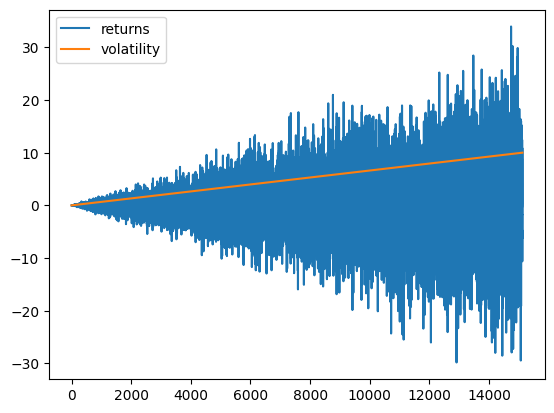

In [25]:

mu = 0
sigma = 1

n = 15
nobs = 252 * 4 * n

df_ret = pd.DataFrame([], columns=['returns'])

for i in range(nobs):
    # mu = random.uniform(-10, 10)
    # sigma = random.uniform(1.00, 10.00)
    sigma = 10 * (i + 1) / nobs
    df_ret.loc[i, 'returns'] = float(np.random.normal(mu, sigma))
    df_ret.loc[i, 'volatility'] = float(sigma)
    # df_ret.loc[i, 'mu'] = float(mu)

df_ret.plot()
# ret = np.random.normal(mu, sigma, nobs)
# df_ret = pd.DataFrame(ret, columns=['returns'])

In [26]:
rolling_window = 22 * 18
n_lag = 5

# df_ret['volatility'] = df_ret['returns'].rolling(rolling_window).std()
# df_ret['mean'] = df_ret['returns'].rolling(rolling_window).mean()

for  i in range(1, n_lag + 1):
    df_ret[f'ret_lag_{i}'] = df_ret['returns'].shift(i)
df_ret.dropna(inplace=True)
df_ret

,returns,volatility,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5
5,-0.00731,0.003968,0.006159,-0.003055,-0.001837,0.000401,0.000615
6,-0.000466,0.004630,-0.00731,0.006159,-0.003055,-0.001837,0.000401
7,-0.003793,0.005291,-0.000466,-0.00731,0.006159,-0.003055,-0.001837
8,0.001483,0.005952,-0.003793,-0.000466,-0.00731,0.006159,-0.003055
9,-0.005749,0.006614,0.001483,-0.003793,-0.000466,-0.00731,0.006159
...,...,...,...,...,...,...,...
15115,-10.621907,9.997354,6.761495,2.859155,10.888645,-1.8226,-1.317912
15116,4.28153,9.998016,-10.621907,6.761495,2.859155,10.888645,-1.8226
15117,-4.782457,9.998677,4.28153,-10.621907,6.761495,2.859155,10.888645
15118,-6.232669,9.999339,-4.782457,4.28153,-10.621907,6.761495,2.859155


In [27]:
df_y = df_ret['returns']
df_X = df_ret.drop(columns=['returns'])

X_tensor = torch.tensor(np.array(df_X.astype(float)), dtype=torch.float32)
y_tensor = torch.tensor(np.array(df_y.astype(float)), dtype=torch.float32).unsqueeze(1)
valid_dates = df_X.index
input_dim = df_X.shape[1]


In [28]:
# nobs = 252 * 4 * 6

initial_train_size = 252 * 4 * (n - 2)
step_size = 252 * 4 * 2

# 1. Unpack only the 3 returned variables!
predicted_quantiles_matrix, oos_dates, actual_returns = run_quantile_model(
    X_tensor, 
    y_tensor, 
    valid_dates, 
    initial_train_size, 
    step_size
)

# 2. Pass the quantiles matrix into the NEW generator
predicted_ensembles = generate_monte_carlo_from_skeleton(
    predicted_quantiles_matrix, 
    n_samples=1000
)

# Convert actual returns to a Pandas Series with proper dates
actual_arr = np.array(actual_returns)
actual_series = pd.Series(actual_arr, index=oos_dates)

# ==========================================
# 2. RUN THE METRICS PIPELINE
# ==========================================
print("Evaluating Forecasts (PIT, CRPS, Log-Likelihood)...")
df_eval = evaluate_forecasts(actual_series, predicted_ensembles)

# df_block_ks_test = block_ks_test(df_eval['PIT'], block_size=22 * 6)
# print(df_block_ks_test)

# Saving the dictionary to a file

Evaluating Forecasts (PIT, CRPS, Log-Likelihood)...


In [29]:
df_block_ks_test = block_ks_test(df_eval['PIT'], block_size=22 * 6)
print(df_block_ks_test)


--- INDEPENDENT BLOCK TEST SUMMARY (132-Day Windows) ---
Total Independent Blocks: 15
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
    Start_Date  End_Date   KS_Stat   P_Value    Status
0        13109     13240  0.060303  0.700019  ✅ PASSED
1        13241     13372  0.063515  0.637811  ✅ PASSED
2        13373     13504  0.090545  0.215839  ✅ PASSED
3        13505     13636  0.064727  0.614338  ✅ PASSED
4        13637     13768  0.058121  0.741583  ✅ PASSED
5        13769     13900  0.067121  0.568439  ✅ PASSED
6        13901     14032  0.085697  0.271119  ✅ PASSED
7        14033     14164  0.054364  0.809776  ✅ PASSED
8        14165     14296  0.061818  0.670738  ✅ PASSED
9        14297     14428  0.077182  0.391422  ✅ PASSED
10       14429     14560  0.111606  0.069012  ✅ PASSED
11       14561     14692  0.086909  0.256416  ✅ PASSED
12       14693     14824  0.095212  0.171171  ✅ PASSED
13       14825     14956  0.090788  0.213318  ✅ PASSED
14       14957     15088  0.0

<Axes: >

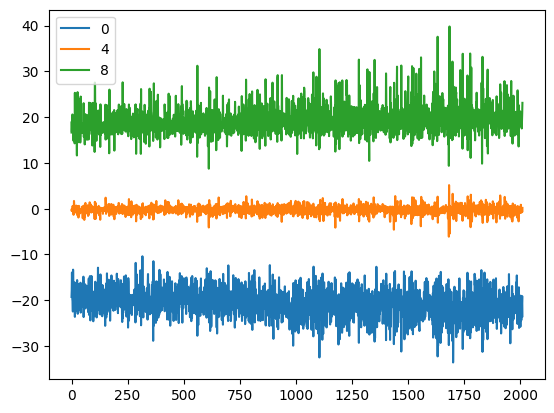

In [30]:
# from scipy.stats import norm

# # Parameters for the distribution
# mu = 0       # Mean
# sigma = 1    # Standard deviation

# # Calculate the 95th percentile (0.95 quantile)
# theorical_quantile = [float(norm.ppf(q, loc=mu, scale=sigma)) for q in QUANTILES]

pd.DataFrame(predicted_quantiles_matrix)[[0, 4, 8]].plot()



In [31]:
# df_eval


--- INDEPENDENT BLOCK TEST SUMMARY (2011-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,13109,15119,0.035873,0.011027,❌ FAILED


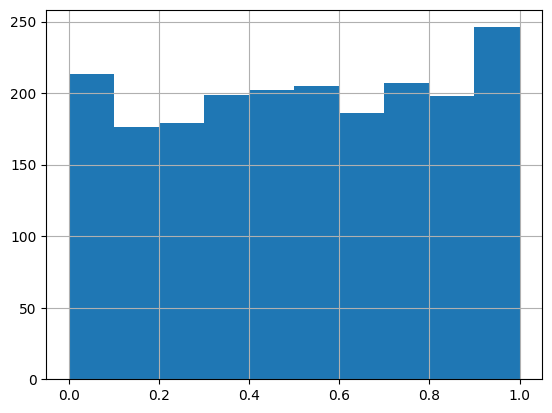

In [32]:
n = int(len(df_eval) / 1)

df_eval.iloc[:]['PIT'].hist()
df_block_ks_test = block_ks_test(df_eval['PIT'], block_size=n)
df_block_ks_test

In [33]:

df_block_ks_test.head(24)


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,13109,15119,0.035873,0.011027,❌ FAILED


In [34]:
STOP

NameError: name 'STOP' is not defined

# New model 1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
class SanityQuantileNet(nn.Module):
    def __init__(self, input_dim=5):
        super(SanityQuantileNet, self).__init__()
        hidden_dim = 8
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Slightly more neurons to help with the offsets
            nn.ReLU()
        )
        
        # We split the output into two parts:
        # 1. The baseline (the lowest quantile Q0.01)
        self.q_base = nn.Linear(hidden_dim, 1)
        
        # 2. The positive steps to reach the next 8 quantiles
        self.q_offsets = nn.Sequential(
            nn.Linear(hidden_dim, len(QUANTILES) - 1),
            nn.Softplus() # Forces all outputs to be strictly > 0
        )
        

    def forward(self, x):
        h = self.hidden(x)
        
        # Base prediction for the 1st percentile (can be negative or positive)
        base = self.q_base(h) 
        
        # The positive steps for the remaining quantiles
        offsets = self.q_offsets(h)
        
        # We mathematically stack them by taking the cumulative sum!
        # [base, base + offset1, base + offset1 + offset2, ...]
        quantiles = torch.cat([base, offsets], dim=1)
        sorted_outputs = torch.cumsum(quantiles, dim=1)
        
        return sorted_outputs

def weighted_pinball_loss(predictions, target, quantiles, weights):
    """
    Calculates the Quantile Loss but applies custom multipliers to force 
    the network to prioritize the extreme tails.
    """
    losses = []
    for i, q in enumerate(quantiles):
        error = target - predictions[:, i:i+1]
        
        # Standard Pinball logic
        loss_for_q = torch.max(q * error, (q - 1.0) * error)
        
        # THE FIX: Multiply the loss by our custom tail weight!
        loss_for_q = loss_for_q * weights[i]
        
        losses.append(loss_for_q)
        
    return torch.cat(losses, dim=1).mean()

In [ ]:
# ==========================================
# 1. GENERATE PERFECT SYNTHETIC NORMAL DATA
# ==========================================
np.random.seed(42)
torch.manual_seed(42)

mu_true = -0.501
sigma_true = 1
N_days = 10000
train_size = 8000


# Generate pure normal returns
synthetic_returns = np.random.normal(mu_true, sigma_true, N_days)
df_returns = pd.DataFrame(synthetic_returns, columns=['returns'])
rolling_window = 22 * 12
n_lag = 2

df_returns['volatility'] = df_returns['returns'].rolling(rolling_window).std()
df_returns['mean'] = df_returns['returns'].rolling(rolling_window).mean()

for  i in range(1, n_lag + 1):
    df_returns[f'returns_lag_{i}'] = df_returns['returns'].shift(i)
df_returns.dropna(inplace=True)
df_returns

,returns,volatility,mean,returns_lag_1,returns_lag_2
263,-1.525388,0.990848,-0.513394,-3.742267,-0.560525
264,-0.753568,0.990457,-0.516233,-1.525388,-3.742267
265,-1.748783,0.993331,-0.520435,-0.753568,-1.525388
266,1.131411,0.997685,-0.516705,-1.748783,-0.753568
267,-1.931141,0.996922,-0.527892,1.131411,-1.748783
...,...,...,...,...,...
9995,0.800102,0.951729,-0.526227,0.693214,-1.999635
9996,-2.499345,0.956066,-0.538605,0.800102,0.693214
9997,-1.206317,0.954048,-0.536561,-2.499345,0.800102
9998,-0.005234,0.950732,-0.539825,-1.206317,-2.499345


In [ ]:
df_y = df_returns['returns']
df_X = df_returns.drop(columns=['returns'])

X_tensor = torch.tensor(np.array(df_X), dtype=torch.float32)
y_tensor = torch.tensor(np.array(df_y), dtype=torch.float32).unsqueeze(1)


# Split into Train/Test
X_train, y_train = X_tensor[:train_size], y_tensor[:train_size]
X_test, y_test = X_tensor[train_size:], y_tensor[train_size:]

# ==========================================
# 2. THE QUANTILE NETWORK & PINBALL LOSS
# ==========================================
QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
# Emphasize the 1% and 99% tails by 10x!
QUANTILE_WEIGHTS = [10.0,  5.0,  2.0,  1.0,  1.0,  1.0,  2.0,  5.0, 10.0]


Training Sanity Check Model...


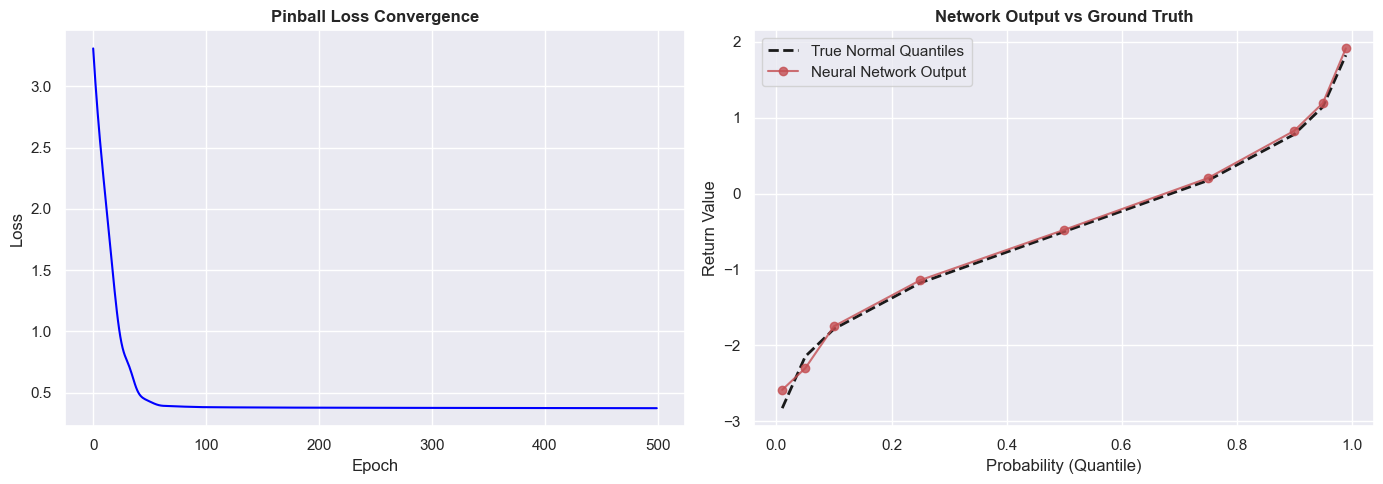


--- Quantile Comparison ---
Q0.01 | True: -2.8273 | NN Predicted: -2.5852
Q0.05 | True: -2.1459 | NN Predicted: -2.3006
Q0.10 | True: -1.7826 | NN Predicted: -1.7473
Q0.25 | True: -1.1755 | NN Predicted: -1.1400
Q0.50 | True: -0.5010 | NN Predicted: -0.4774
Q0.75 | True:  0.1735 | NN Predicted:  0.2044
Q0.90 | True:  0.7806 | NN Predicted:  0.8275
Q0.95 | True:  1.1439 | NN Predicted:  1.1938
Q0.99 | True:  1.8253 | NN Predicted:  1.9147


In [ ]:
# ==========================================
# 3. TRAIN THE MODEL
# ==========================================

model = SanityQuantileNet(input_dim=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

epochs = 500
losses = []

print("Training Sanity Check Model...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    preds = model(X_train)
    loss = weighted_pinball_loss(preds, y_train, QUANTILES, QUANTILE_WEIGHTS)
    # loss = pinball_loss(preds, y_train, QUANTILES)
    
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# ==========================================
# 4. EVALUATE VS THEORETICAL TRUTH
# ==========================================
model.eval()
with torch.no_grad():
    test_preds = model(X_test)

# Because the input is noise, the network should output roughly the same 
# quantiles every single day. Let's take the average of its predictions.
avg_predicted_quantiles = test_preds.mean(dim=0).numpy()

# Calculate the EXACT theoretical quantiles of the underlying Normal Distribution
theoretical_quantiles = stats.norm.ppf(QUANTILES, loc=mu_true, scale=sigma_true)

# ==========================================
# 5. VISUALIZATION
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Loss Curve
axes[0].plot(losses, color='blue')
axes[0].set_title("Pinball Loss Convergence", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Plot 2: Predicted vs Theoretical Quantiles
axes[1].plot(QUANTILES, theoretical_quantiles, 'k--', linewidth=2, label="True Normal Quantiles")
axes[1].plot(QUANTILES, avg_predicted_quantiles, 'ro-', markersize=6, alpha=0.8, label="Neural Network Output")
axes[1].set_title("Network Output vs Ground Truth", fontweight='bold')
axes[1].set_xlabel("Probability (Quantile)")
axes[1].set_ylabel("Return Value")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the exact numbers for comparison
print("\n--- Quantile Comparison ---")
for i, q in enumerate(QUANTILES):
    print(f"Q{q:4.2f} | True: {theoretical_quantiles[i]:>7.4f} | NN Predicted: {avg_predicted_quantiles[i]:>7.4f}")

In [ ]:
stop

NameError: name 'stop' is not defined

Training Sanity Check Model...


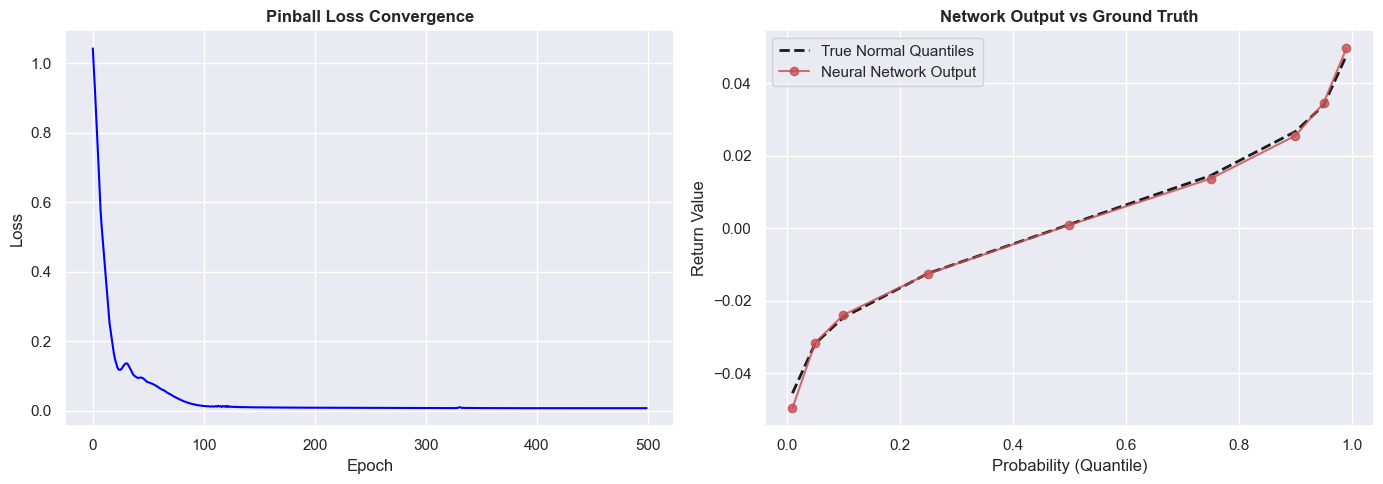


--- Quantile Comparison ---
Q0.01 | True: -0.0455 | NN Predicted: -0.0497
Q0.05 | True: -0.0319 | NN Predicted: -0.0317
Q0.10 | True: -0.0246 | NN Predicted: -0.0240
Q0.25 | True: -0.0125 | NN Predicted: -0.0126
Q0.50 | True:  0.0010 | NN Predicted:  0.0009
Q0.75 | True:  0.0145 | NN Predicted:  0.0136
Q0.90 | True:  0.0266 | NN Predicted:  0.0255
Q0.95 | True:  0.0339 | NN Predicted:  0.0345
Q0.99 | True:  0.0475 | NN Predicted:  0.0495


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. GENERATE PERFECT SYNTHETIC NORMAL DATA
# ==========================================
np.random.seed(42)
torch.manual_seed(42)

mu_true = 0.001
sigma_true = 0.020
N_days = 5000
window_size = 5

# Generate pure normal returns
synthetic_returns = np.random.normal(mu_true, sigma_true, N_days)

X_data = []
y_data = []

# Create 5-day rolling windows
for i in range(len(synthetic_returns) - window_size):
    X_data.append(synthetic_returns[i : i + window_size])
    y_data.append(synthetic_returns[i + window_size])

X_tensor = torch.tensor(np.array(X_data), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y_data), dtype=torch.float32).unsqueeze(1)

# Split into Train/Test
train_size = 4000
X_train, y_train = X_tensor[:train_size], y_tensor[:train_size]
X_test, y_test = X_tensor[train_size:], y_tensor[train_size:]

# ==========================================
# 2. THE QUANTILE NETWORK & PINBALL LOSS
# ==========================================
# QUANTILES = [0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
# Emphasize the 1% and 99% tails by 10x!
QUANTILE_WEIGHTS = [10.0,  5.0,  2.0,  1.0,  1.0,  1.0,  2.0,  5.0, 10.0]

class MedianAnchoredQuantileNet(nn.Module):
    def __init__(self, input_dim=5):
        super(MedianAnchoredQuantileNet, self).__init__()
        
        inner_dim = 16
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, inner_dim),
            nn.ReLU()
        )
        
        # 1. The Core Anchor (Median)
        self.median_head = nn.Linear(inner_dim, 1)
        
        # 2. Four steps going UP (for Q75, Q90, Q95, Q99)
        self.right_offsets = nn.Sequential(
            nn.Linear(inner_dim, 4),
            nn.Softplus() # Strictly positive
        )
        
        # 3. Four steps going DOWN (for Q25, Q10, Q05, Q01)
        self.left_offsets = nn.Sequential(
            nn.Linear(inner_dim, 4),
            nn.Softplus() # Strictly positive
        )
        
    def forward(self, x):
        h = self.hidden(x)
        
        median = self.median_head(h)
        
        # Calculate the positive distances
        right_steps = self.right_offsets(h)
        left_steps = self.left_offsets(h)
        
        # Cumulative sum going RIGHT: [step1, step1+step2, ...]
        cum_right = torch.cumsum(right_steps, dim=1)
        q_75 = median + cum_right[:, 0:1]
        q_90 = median + cum_right[:, 1:2]
        q_95 = median + cum_right[:, 2:3]
        q_99 = median + cum_right[:, 3:4]
        
        # Cumulative sum going LEFT: [step1, step1+step2, ...]
        cum_left = torch.cumsum(left_steps, dim=1)
        q_25 = median - cum_left[:, 0:1]
        q_10 = median - cum_left[:, 1:2]
        q_05 = median - cum_left[:, 2:3]
        q_01 = median - cum_left[:, 3:4]
        
        # Concatenate them back into the exact order expected by the Pinball Loss!
        # Order: 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99
        quantiles = torch.cat([
            q_01, q_05, q_10, q_25, 
            median, 
            q_75, q_90, q_95, q_99
        ], dim=1)
        
        return quantiles

# Note: In your training loop, make sure you instantiate this new class!
# model = MedianAnchoredQuantileNet(input_dim=window_size)

class SanityQuantileNet(nn.Module):
    def __init__(self, input_dim=5):
        super(SanityQuantileNet, self).__init__()
        
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, 16), # Slightly more neurons to help with the offsets
            nn.ReLU()
        )
        
        # We split the output into two parts:
        # 1. The baseline (the lowest quantile Q0.01)
        self.q_base = nn.Linear(16, 1)
        
        # 2. The positive steps to reach the next 8 quantiles
        self.q_offsets = nn.Sequential(
            nn.Linear(16, len(QUANTILES) - 1),
            nn.Softplus() # Forces all outputs to be strictly > 0
        )
        
        # nn.init.uniform_(self.right_offsets[0].weight, -0.01, 0.01)
        # nn.init.constant_(self.right_offsets[0].bias, 0.01)
        
        # nn.init.uniform_(self.left_offsets[0].weight, -0.01, 0.01)
        # nn.init.constant_(self.left_offsets[0].bias, 0.01)

    def forward(self, x):
        h = self.hidden(x)
        
        # Base prediction for the 1st percentile (can be negative or positive)
        base = self.q_base(h) 
        
        # The positive steps for the remaining quantiles
        offsets = self.q_offsets(h)
        
        # We mathematically stack them by taking the cumulative sum!
        # [base, base + offset1, base + offset1 + offset2, ...]
        quantiles = torch.cat([base, offsets], dim=1)
        sorted_outputs = torch.cumsum(quantiles, dim=1)
        
        return sorted_outputs

def weighted_pinball_loss(predictions, target, quantiles, weights):
    """
    Calculates the Quantile Loss but applies custom multipliers to force 
    the network to prioritize the extreme tails.
    """
    losses = []
    for i, q in enumerate(quantiles):
        error = target - predictions[:, i:i+1]
        
        # Standard Pinball logic
        loss_for_q = torch.max(q * error, (q - 1.0) * error)
        
        # THE FIX: Multiply the loss by our custom tail weight!
        loss_for_q = loss_for_q * weights[i]
        
        losses.append(loss_for_q)
        
    return torch.cat(losses, dim=1).mean()

def pinball_loss(predictions, target, quantiles):
    losses = []
    for i, q in enumerate(quantiles):
        error = target - predictions[:, i:i+1]
        loss_for_q = torch.max(q * error, (q - 1.0) * error)
        losses.append(loss_for_q)
    return torch.cat(losses, dim=1).mean()

# ==========================================
# 3. TRAIN THE MODEL
# ==========================================

# model = MedianAnchoredQuantileNet(input_dim=window_size)

model = SanityQuantileNet(input_dim=window_size)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

epochs = 500
losses = []

print("Training Sanity Check Model...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    preds = model(X_train)
    loss = weighted_pinball_loss(preds, y_train, QUANTILES, QUANTILE_WEIGHTS)
    # loss = pinball_loss(preds, y_train, QUANTILES)
    
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# ==========================================
# 4. EVALUATE VS THEORETICAL TRUTH
# ==========================================
model.eval()
with torch.no_grad():
    test_preds = model(X_test)

# Because the input is noise, the network should output roughly the same 
# quantiles every single day. Let's take the average of its predictions.
avg_predicted_quantiles = test_preds.mean(dim=0).numpy()

# Calculate the EXACT theoretical quantiles of the underlying Normal Distribution
theoretical_quantiles = stats.norm.ppf(QUANTILES, loc=mu_true, scale=sigma_true)

# ==========================================
# 5. VISUALIZATION
# ==========================================
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Loss Curve
axes[0].plot(losses, color='blue')
axes[0].set_title("Pinball Loss Convergence", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Plot 2: Predicted vs Theoretical Quantiles
axes[1].plot(QUANTILES, theoretical_quantiles, 'k--', linewidth=2, label="True Normal Quantiles")
axes[1].plot(QUANTILES, avg_predicted_quantiles, 'ro-', markersize=6, alpha=0.8, label="Neural Network Output")
axes[1].set_title("Network Output vs Ground Truth", fontweight='bold')
axes[1].set_xlabel("Probability (Quantile)")
axes[1].set_ylabel("Return Value")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the exact numbers for comparison
print("\n--- Quantile Comparison ---")
for i, q in enumerate(QUANTILES):
    print(f"Q{q:4.2f} | True: {theoretical_quantiles[i]:>7.4f} | NN Predicted: {avg_predicted_quantiles[i]:>7.4f}")